# Test enviroment

### imports

In [1]:
import gymnasium as gym
# Run `pip install "gymnasium[classic-control]"` for this example.

### 100 episodes test

In [2]:
env = gym.make("CartPole-v0", render_mode="rgb_array")
env.reset()

frames = []

for i_episode in range(100):
    obs = env.reset()
    t = 0
    done = False
    while not done:
        if i_episode >= 97:
            frames.append(env.render())

        env.render()
        action = env.action_space.sample()
        obs,reward, terminated, truncated,info = env.step(action)
        t += 1
        done = terminated or truncated
        if done:
            print("Done after {} steps".format(t))
            break
env.close()


c:\Users\i7\AppData\Local\Programs\Python\Python310\lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


Done after 13 steps
Done after 15 steps
Done after 28 steps
Done after 24 steps
Done after 56 steps
Done after 22 steps
Done after 23 steps
Done after 14 steps
Done after 19 steps
Done after 52 steps
Done after 20 steps
Done after 18 steps
Done after 15 steps
Done after 46 steps
Done after 60 steps
Done after 24 steps
Done after 15 steps
Done after 24 steps
Done after 16 steps
Done after 39 steps
Done after 28 steps
Done after 20 steps
Done after 23 steps
Done after 24 steps
Done after 15 steps
Done after 12 steps
Done after 29 steps
Done after 26 steps
Done after 12 steps
Done after 15 steps
Done after 17 steps
Done after 14 steps
Done after 13 steps
Done after 15 steps
Done after 29 steps
Done after 17 steps
Done after 12 steps
Done after 18 steps
Done after 18 steps
Done after 36 steps
Done after 16 steps
Done after 10 steps
Done after 28 steps
Done after 12 steps
Done after 22 steps
Done after 12 steps
Done after 20 steps
Done after 30 steps
Done after 21 steps
Done after 15 steps


In [14]:
print(obs[0])

0.1449626


### Animation imports

In [3]:
from IPython import display as ipythondisplay
from PIL import Image
import numpy as np

### Animation

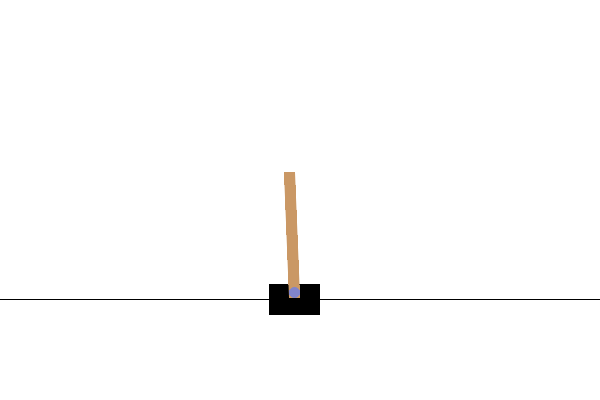

In [4]:
if frames:
    img_frames = [Image.fromarray(f) for f in frames]
    # Guardar el GIF
    img_frames[0].save(
        'cartpole_run.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=50,  # Milisegundos por frame
        loop=0
    )
    # Mostrar el GIF en el Notebook
    ipythondisplay.display(ipythondisplay.Image(data='cartpole_run.gif'))

# Q-LEARNING ALGORITHM

### imports

In [5]:
import random, math
import numpy as np
import matplotlib.pyplot as plt

### Evniroment initialize, Q-table discretize

In [6]:
env= gym.make('CartPole-v1')

no_buckets = (1,1,6,3)
no_actions = env.action_space.n

state_value_bounds = list(zip(env.observation_space.low, 
                              env.observation_space.high))
state_value_bounds[1] = (-0.5, 0.5)
state_value_bounds[3] = (-math.radians(50), math.radians(50))

print(state_value_bounds)
print(len(state_value_bounds))
print(np.shape(state_value_bounds))
print(state_value_bounds[0][0])


action_index = len(no_buckets)   # i am not using this

# define q_value_table
q_value_table = np.zeros(no_buckets + (no_actions,))

# Q has 6 dimensions 1 x 1 x 6 x 3 x 2 
#print(q_value_table)


# user-defined parameters
min_explore_rate = 0.1
min_learning_rate = 0.1
max_episodes = 1000
max_time_steps = 250
streak_to_end = 120
solved_time = 199
discount = 0.99
no_streaks = 0

[(np.float32(-4.8), np.float32(4.8)), (-0.5, 0.5), (np.float32(-0.41887903), np.float32(0.41887903)), (-0.8726646259971648, 0.8726646259971648)]
4
(4, 2)
-4.8


### Functions definition

In [7]:
def select_action(state_value, explore_rate):
    if random.random() < explore_rate: 
        action = env.action_space.sample()    # explore
    else:
        action = np.argmax(q_value_table[state_value])  # exploit
    return action

def select_explore_rate(x):
    # change the exploration rate over time.
    return max(min_learning_rate, min(1.0, 1.0 - math.log10((x+1)/25)))

def select_learning_rate(x):
    # Change learning rate over time
    return max(min_learning_rate, min(1.0, 1.0 - math.log10((x+1)/25)))

def bucketize_state_value(state_value):
    ''' Discretizes continuous values into fixed buckets'''
    #print('len(state_value):', len(state_value))
    bucket_indices = []
    for i in range(len(state_value)):
        if state_value[i] <= state_value_bounds[i][0]:   # violates lower bound
            bucket_index = 0
        elif state_value[i] >= state_value_bounds[i][1]: # violates upper bound
            bucket_index = no_buckets[i] - 1  # put in the last bucket
        else:
            bound_width = state_value_bounds[i][1] - state_value_bounds[i][0]
            offset = (no_buckets[i]-1) * state_value_bounds[i][0] / bound_width
            scaling = (no_buckets[i]-1) / bound_width
            bucket_index = int(round(scaling*state_value[i]-offset))

        bucket_indices.append(bucket_index)
    return(tuple(bucket_indices))

def discretize(obs):
    ''' Does the same job as bucketize'''
    upper_bounds = [state_value_bounds[i][1] for i in range(len(obs))]
    lower_bounds = [state_value_bounds[i][0] for i in range(len(obs))]
    ratios = [(obs[i] + abs(lower_bounds[i]))/ 
            (upper_bounds[i] - lower_bounds[i]) for i in range(len(obs))]
    new_obs = [int(round((no_buckets[i] - 1) * ratios[i])) for i in range(len(obs))]
    new_obs = [min(no_buckets[i] - 1, max(0, new_obs[i])) for i in range(len(obs))]
    return tuple(new_obs)

### Training

In [8]:
_DEBUG = False
frames = []
reward_per_episode = []
time_per_episode = []
avgtime_per_episode = []
learning_rate_per_episode = []
explore_rate_per_episode = []


totaltime = 0
for episode_no in range(max_episodes):

    explore_rate = select_explore_rate(episode_no)
    learning_rate = select_learning_rate(episode_no)

    learning_rate_per_episode.append(learning_rate)
    explore_rate_per_episode.append(explore_rate)

    # reset the environment while starting a new episode
    observation = env.reset()
    #print('-------------------------------------------------')
    #print(observation[0])
    #print('-------------------------------------------------')
    start_state_value = bucketize_state_value(observation[0])
    previous_state_value = start_state_value


    done = False 
    time_step = 0

    while not done:  
        #env.render()
        action = select_action(previous_state_value, explore_rate)
        observation, reward,  terminated, truncated, info = env.step(action)
        state_value = bucketize_state_value(observation)
        best_q_value = np.max(q_value_table[state_value])

        #update q_value_table
        q_value_table[previous_state_value][action] += learning_rate * (
            reward + discount * best_q_value - 
            q_value_table[previous_state_value][action])

        previous_state_value = state_value
        
        if episode_no % 100 == 0 and _DEBUG == True:
            print('Episode number: {}'.format(episode_no))
            print('Time step: {}'.format(time_step))
            print('Previous State Value: {}'.format(previous_state_value))
            print('Selected Action: {}'.format(action))
            print('Current State: {}'.format(str(state_value)))
            print('Reward Obtained: {}'.format(reward))
            print('Best Q Value: {}'.format(best_q_value))
            print('Learning rate: {}'.format(learning_rate))
            print('Explore rate: {}'.format(explore_rate))

        time_step += 1
        # while loop ends here
        done = terminated or truncated

    if time_step >= solved_time:
        no_streaks += 1
    else:
        no_streaks = 0

    if no_streaks > streak_to_end:
        print('CartPole problem is solved after {} episodes.'.format(episode_no))

        break

    # data log
    if episode_no % 100 == 0:  
        print('Episode {} finished after {} time steps'.format(episode_no, time_step))
    time_per_episode.append(time_step)
    totaltime += time_step
    avgtime_per_episode.append(totaltime/(episode_no+1))
    # episode loop ends here
 
env.close()

Episode 0 finished after 84 time steps
Episode 100 finished after 13 time steps
Episode 200 finished after 500 time steps
Episode 300 finished after 500 time steps
Episode 400 finished after 500 time steps
CartPole problem is solved after 493 episodes.


### Training plot graph

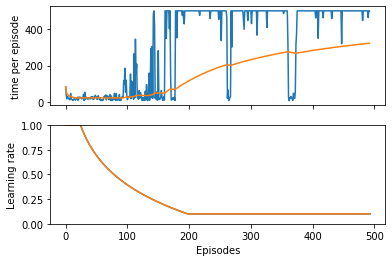

In [9]:
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(time_per_episode)
axes[0].plot(avgtime_per_episode)
axes[0].set(ylabel='time per episode')
axes[1].plot(learning_rate_per_episode)
axes[1].plot(explore_rate_per_episode)
axes[1].set_ylim([0,1])
axes[1].set(xlabel='Episodes', ylabel='Learning rate')
plt.savefig("cp_qlearn_plot.png")
plt.show()

### Result animation

Episode number: 493


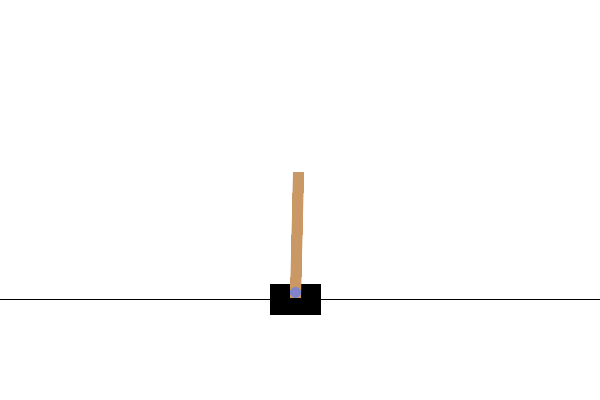

In [10]:
env= gym.make('CartPole-v1', render_mode="rgb_array")
explore_rate = select_explore_rate(episode_no)
learning_rate = select_learning_rate(episode_no)

learning_rate_per_episode.append(learning_rate)
explore_rate_per_episode.append(explore_rate)

# reset the environment while starting a new episode
observation = env.reset()
start_state_value = bucketize_state_value(observation[0])
previous_state_value = start_state_value


done = False 
time_step = 0

frames_q = []

while not done:
    frames_q.append(env.render())  
    #env.render()
    action = select_action(previous_state_value, explore_rate)
    observation, reward,  terminated, truncated, info = env.step(action)
    state_value = bucketize_state_value(observation)
    best_q_value = np.max(q_value_table[state_value])

    #update q_value_table
    q_value_table[previous_state_value][action] += learning_rate * (
        reward + discount * best_q_value - 
        q_value_table[previous_state_value][action])

    previous_state_value = state_value
    
    time_step += 1
    # while loop ends here
    done = terminated or truncated

print('Episode number: {}'.format(episode_no))
if frames_q:
    img_frames = [Image.fromarray(f) for f in frames_q]
    # Guardar el GIF
    img_frames[0].save(
        'cartpole_run.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=50,  # Milisegundos por frame
        loop=0
    )
    # Mostrar el GIF en el Notebook
    ipythondisplay.display(ipythondisplay.Image(data='cartpole_run.gif'))

# Deep Q-Learning